## Nome: Pedro Henrique de Paiva Carvalho
## Matrícula: 2162

# Atividade 6 — Refinamento de Raízes: Método de Newton-Raphson
## Contexto: Nós de uma Função de Onda Quântica

Na disciplina de F04 (Física Moderna e Quântica), os **nós de uma função de onda** representam posições nas quais a amplitude de probabilidade é nula. Em um modelo simplificado relacionado ao oscilador harmônico quântico, a parte polinomial de uma função de onda pode ser representada por:

$$\psi(x)=4x^3-6x$$

Para aplicar o método de Newton-Raphson, utiliza-se sua derivada:

$${\psi}'(x)=12x^2-6$$

Nesta atividade, o objetivo é localizar numericamente os valores de $x$ para os quais $\psi(x)=0$ e analisar como o chute inicial e a tolerância influenciam a convergência.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 4*x**3 - 6*x

def df(x):
    return 12*x**2 - 6

In [3]:
def newton_raphson(x0, tol=1e-9, max_iter=100):
    x = x0
    for i in range(max_iter):
        if abs(f(x)) < tol:
            return x, i
        if abs(df(x)) < 1e-12:
            raise ValueError("Derivada muito próxima de zero. Escolha outro chute inicial.")
        x = x - f(x)/df(x)
    return x, max_iter

## Parte Prática
1. Plote $f(x)$ no intervalo $[-2;2]$, indicando com uma linha tracejada o eixo $y=0$ e identificando visualmente as possíveis raízes.

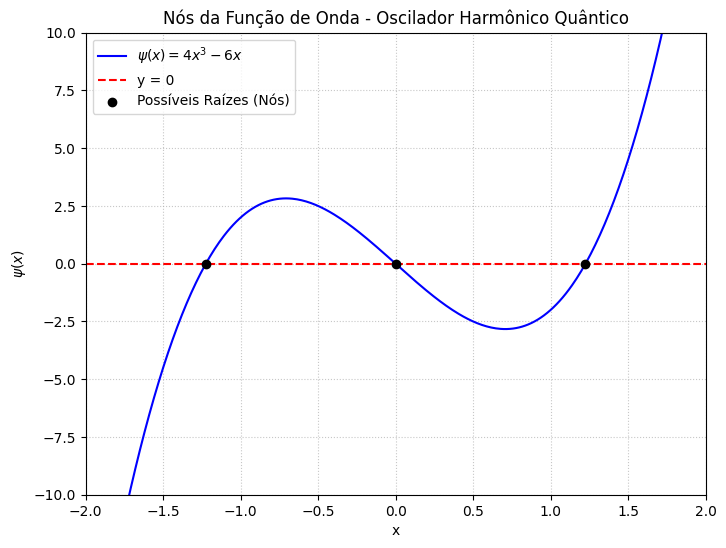

In [4]:
def f(x):
    return 4*x**3 - 6*x

x_vals = np.linspace(-2, 2, 400)
y_vals = f(x_vals)

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label=r'$\psi(x) = 4x^3 - 6x$', color='blue')
plt.axhline(0, color='red', linestyle='--', label='y = 0')

raizes_x = [-np.sqrt(1.5), 0, np.sqrt(1.5)]
raizes_y = [0, 0, 0]
plt.scatter(raizes_x, raizes_y, color='black', zorder=5, label='Possíveis Raízes (Nós)')

plt.title('Nós da Função de Onda - Oscilador Harmônico Quântico')
plt.xlabel('x')
plt.ylabel(r'$\psi(x)$')
plt.xlim([-2, 2])
plt.ylim([-10, 10])
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.show()

2. Aplique o método de Newton-Raphson utilizando o chute inicial $x_0=1{,}8$. Apresente a raiz aproximada e o número de iterações.

In [5]:
def f(x):
    return 4*x**3 - 6*x

def df(x):
    return 12*x**2 - 6

def newton_raphson(x0, tol=1e-9, max_iter=100):
    x = x0
    for i in range(max_iter):
        if abs(f(x)) < tol:
            return x, i
        if abs(df(x)) < 1e-12:
            raise ValueError("Derivada muito próxima de zero. Escolha outro chute inicial.")
        x = x - f(x)/df(x)
    return x, max_iter

x0 = 1.8
raiz, iteracoes = newton_raphson(x0)

print(f"Raiz aproximada: {raiz}")
print(f"Número de iterações: {iteracoes}")

Raiz aproximada: 1.2247448713969942
Número de iterações: 5


3. Teste os chutes iniciais $(-2{,}0; -1{,}0; -0{,}4; 0{,}2; 0{,}8; 1{,}6)$ e compare a raiz encontrada e o número de iterações em cada caso.

In [6]:
chutes_iniciais = [-2.0, -1.0, -0.4, 0.2, 0.8, 1.6]

print(f"{'Chute Inicial (x0)':<20} | {'Raiz Encontrada':<20} | {'Iterações'}")
print("-" * 55)

for x0 in chutes_iniciais:
    raiz, iteracoes = newton_raphson(x0)
    print(f"{x0:<20.1f} | {raiz:<20.8f} | {iteracoes}")

Chute Inicial (x0)   | Raiz Encontrada      | Iterações
-------------------------------------------------------
-2.0                 | -1.22474487          | 6
-1.0                 | -1.22474487          | 5
-0.4                 | -0.00000000          | 4
0.2                  | -0.00000000          | 3
0.8                  | 1.22474487           | 7
1.6                  | 1.22474487           | 5


4. Execute o método com as tolerâncias $10^{-3}$, $10^{-6}$ e $10^{-9}$, mantendo $x_0=1{,}8$. Analise o impacto da tolerância na aproximação da raiz e no número de iterações.

In [7]:
x0 = 1.8
tolerancias = [1e-3, 1e-6, 1e-9]

print(f"{'Tolerância':<15} | {'Raiz Encontrada':<20} | {'Iterações'}")
print("-" * 50)

for tol in tolerancias:
    raiz, iteracoes = newton_raphson(x0, tol=tol)
    print(f"{tol:<15.0e} | {raiz:<20.10f} | {iteracoes}")

Tolerância      | Raiz Encontrada      | Iterações
--------------------------------------------------
1e-03           | 1.2247469722         | 4
1e-06           | 1.2247448714         | 5
1e-09           | 1.2247448714         | 5


## Parte Teórica

1. O que significa afirmar que o método de Newton-Raphson possui convergência quadrática próximo de uma raiz simples?

**Resposta:** Significa que o erro da próxima iteração é proporcional ao quadrado do erro atual ($E_{i+1} \approx C \cdot E_i^2$). Na prática, o número de casas decimais exatas praticamente dobra a cada iteração, tornando o método extremamente rápido.

2. Como o método pode ser adaptado quando a derivada da função não está disponível analiticamente?

**Resposta:** Pode-se trocar a derivada por uma aproximação numérica, usando diferenças finitas, por exemplo, $f'(x) \approx \frac{f(x+h) - f(x)}{h}$. Outra opção é o Método da Secante, que não usa a derivada exata, mas sim os dois últimos pontos calculados.

3. Compare o método de Newton-Raphson com o método da bissecção, destacando as vantagens e limitações de cada um.

**Resposta:** Comparando os dois algoritmos, a principal vantagem do método de Newton-Raphson é possuir uma convergência mais rápida que o método da bissecção. Em contrapartida, sua maior desvantagem e limitação é que o método pode divergir, exigindo maior cuidado na escolha do ponto inicial.

4. Quais problemas podem ocorrer durante a aplicação do método de Newton-Raphson? Cite pelo menos três e relacione um deles à possibilidade de a derivada ser igual ou muito próxima de zero.

**Resposta:** Durante a aplicação do método, as tangentes podem conduzir a aproximações que caem fora do intervalo, ou o algoritmo pode acabar gerando aproximações repetidas. Isso acontece porque o método depende muito da escolha inicial do valor de $x_0$. Além disso, uma escolha de $x_0$ muito próxima a um ponto de máximo ou de mínimo da função pode causar divergência no método. É importante lembrar que esses pontos ocorrem exatamente quando a derivada da função é igual a zero, o que pode influenciar diretamente o resultado do método. Portanto, a escolha do valor inicial de $x_0$ é fundamental para o sucesso do método.